# Feature Transformation on Linear Probability Model
**Author:** Thom Daniel C. Yutuc

In this notebook, we will be exploring a **Linear Probability Model (LPM)** with feature transformations.

**Feature transformations** help improve model fit by:
  - Capturing non-linear relationships (e.g., `X²`, `X³`)
  - Modeling interactions between variables (e.g., `X1 * X2`)
  - Reducing skewness in predictors (e.g., `log(X)`)

The transformations we will apply in this notebook are **log** and **polynomial feature transformations**.

We will be using the **US Adult Census Dataset**. Exploratory Data Analysis (EDA) was skipped for a much cleaner notebook, but it is worth noting that the dataset contains a significant amount of **class imbalances** and **outliers**.

## Loading the Dataset and Data Preparation

In [27]:
# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load dataset and check size
data = fetch_openml(data_id=43436, as_frame=True)
df = data.frame
print(f"Data loaded successfully, Dataset Size: {len(df)} rows")

Data loaded successfully, Dataset Size: 32561 rows


In [3]:
# Dropped null values
df_clean = df.dropna()

In [4]:
# Create boolean masks for target variable
df_clean["income_binary"] = (df_clean["income"] == "50K").astype(int)

# Check target class balance
print(df_clean["income_binary"].value_counts())
print(df_clean["income_binary"].value_counts(normalize=True))

income_binary
0    22654
1     7508
Name: count, dtype: int64
income_binary
0    0.751078
1    0.248922
Name: proportion, dtype: float64


In [5]:
# Create dummies
categorical_cols = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]

df_categ = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

In [6]:
# Drop duplicate column
df_categ = df_categ.drop(columns=['income'])

In [7]:
# Fix column name format
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)

In [8]:
# Make data types consistent on all columns
df_categ_final = df_categ.astype(float)
df_categ_final

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_binary,workclass_Local_gov,workclass_Private,workclass_Self_emp_inc,...,native_country_Portugal,native_country_Puerto_Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_TrinadadTobago,native_country_United_States,native_country_Vietnam,native_country_Yugoslavia
1,82.0,132870.0,9.0,0.0,4356.0,18.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,54.0,140359.0,4.0,0.0,3900.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41.0,264663.0,10.0,0.0,3900.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,34.0,216864.0,9.0,0.0,3770.0,45.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,38.0,150601.0,6.0,0.0,3770.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22.0,310152.0,10.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32557,27.0,257302.0,12.0,0.0,0.0,38.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32558,40.0,154374.0,9.0,0.0,0.0,40.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32559,58.0,151910.0,9.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Train-Test Split

In [9]:
# Seperate target and features
X = df_categ_final.loc[:, df_categ_final.columns != 'income_binary'].copy()
y = df_categ_final['income_binary'].copy()

# Create train-test split with stratification for consistency across y distributions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Random Forest Feature Selection
We use Random Forest because it provides a stable feature importance. Compared to Single Decision Tree and Bagging, it reduces overfitting and better identifies relevant features over noise.

In [28]:
rf_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)

In [29]:
# Generate importance scores of each feature (only showing top 20 the rest still prints if you remove .head(20))
importances = rf_model.feature_importances_

importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_rf.head(20)

,Feature,Importance
1,fnlwgt,0.167383
0,age,0.155886
3,capital_gain,0.100561
5,hours_per_week,0.084445
28,marital_status_Married_civ_spouse,0.082382
2,education_num,0.058579
4,capital_loss,0.031988
30,marital_status_Never_married,0.030572
55,sex_Male,0.019608
35,occupation_Exec_managerial,0.018815


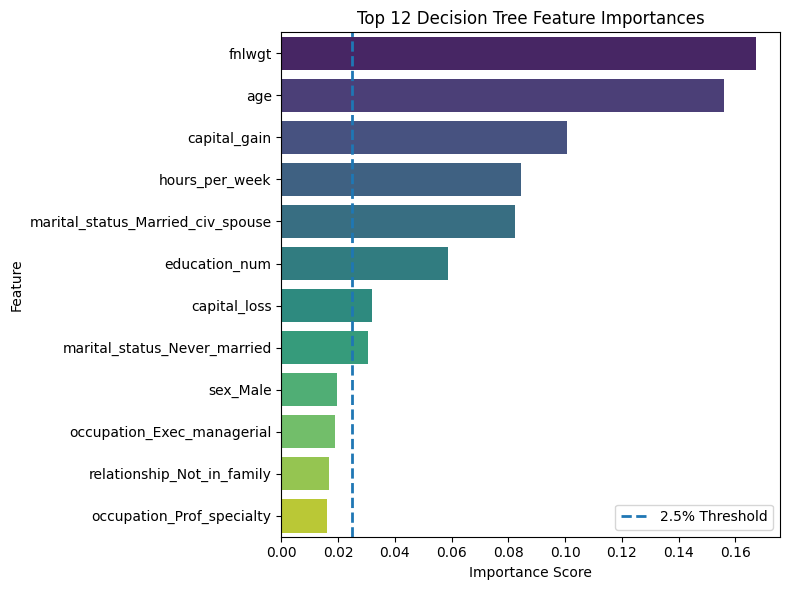

In [30]:
# plot the top 12 with a 2.5% threshold to see which are of real importance)
top_features = importance_rf.sort_values(by="Importance", ascending=False).head(12)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", hue="Feature", data=top_features, palette="viridis", legend=False)

# 2.5% reference line
plt.axvline(x=0.025, linestyle='--', linewidth=2, label='2.5% Threshold')

plt.title("Top 12 Decision Tree Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Extract top 12 features
top_12_features = importance_rf.head(12)["Feature"].tolist()

# Use top 12 features only for X
X_train_selected = X_train[top_12_features]
X_test_selected  = X_test[top_12_features]

## Model Creation
### Concept Notes
The dataset features 97 features with plenty of correlated features. We will focus on lasso regularization in order to feature select and reduce the features.

**Log Transformation**
  - Applies logarithm to the predictor variables (e.g., `log(X)` or `log(1 + X)` for zeros)
  - **Purpose:**
    - Reduces skewness in predictors
    - Compresses large values, expanding small values
    - Helps linear models capture multiplicative or exponential relationships

**Polynomial Transformation**
  - Creates new features that are powers or combinations of existing features (e.g., `X²`, `X1*X2`)
  - **Purpose:**
    - Captures non-linear relationships between predictors and the target
    - Models interactions between variables
    - Improves model fit without changing the algorithm

### Basic Models

In [34]:
# Linear Probability Model (Base)
lpm = LinearRegression().fit(X_train_selected, y_train)

y_pred = lpm.predict(X_train_selected)
y_pred_class = (y_pred >= 0.5).astype(int)

acc_lpm = accuracy_score(y_train, y_pred_class)

print(f"Base LPM Train Accuracy: {acc_lpm:.4f}")

Base LPM Train Accuracy: 0.8266


# Log Transformed Models

**Notes**

- **FunctionTransformer** – applies a custom function to the features
- **np.log1p** – computes `log(1 + X)`; safe for features that include 0
- **validate=True** – ensures the input is a 2D array, preventing shape errors
- **make_pipeline** – chains multiple steps into one object; here it applies the log transform first, then fits the model

In [35]:
# Log Transformer
log_transformer = FunctionTransformer(np.log1p, validate=True)

In [36]:
# Base LPM with Log Transform
lpm_log = make_pipeline(log_transformer, LinearRegression()).fit(X_train_selected, y_train)

y_pred_log = lpm_log.predict(X_train_selected)
y_pred_class_log = (y_pred_log >= 0.5).astype(int)
acc_lpm_log = accuracy_score(y_train, y_pred_class_log)

print(f"Base LPM (Log) Train Accuracy: {acc_lpm_log:.4f}")

Base LPM (Log) Train Accuracy: 0.8308


### Polynomial Transformated Models

**Notes**

- **PolynomialFeatures** – generates polynomial features from your input data
- **degree=2** – creates all powers of features up to 2, including squared terms and pairwise interactions
- **include_bias=False** – prevents adding a constant column of 1s, since most models handle the intercept automatically

In [37]:
# Polynomial Transformers
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)

In [38]:
# Base LPM with Polynomial Transform
lpm_poly = make_pipeline(poly_transformer, LinearRegression()).fit(X_train_selected, y_train)

y_pred_poly = lpm_poly.predict(X_train_selected)
y_pred_class_poly = (y_pred_poly >= 0.5).astype(int)
acc_lpm_poly = accuracy_score(y_train, y_pred_class_poly)

print(f"Base LPM (Poly) Train Accuracy: {acc_lpm_poly:.4f}")

Base LPM (Poly) Train Accuracy: 0.8447


## Model Comparison + Evaluation Metrics

In [40]:
# Base
y_pred_base = lpm.predict(X_test_selected)
y_pred_base_class = (y_pred_base >= 0.5).astype(int)

# Log
y_pred_log = lpm_log.predict(X_test_selected)
y_pred_log_class = (y_pred_log >= 0.5).astype(int)

# Poly
y_pred_poly = lpm_poly.predict(X_test_selected)
y_pred_poly_class = (y_pred_poly >= 0.5).astype(int)

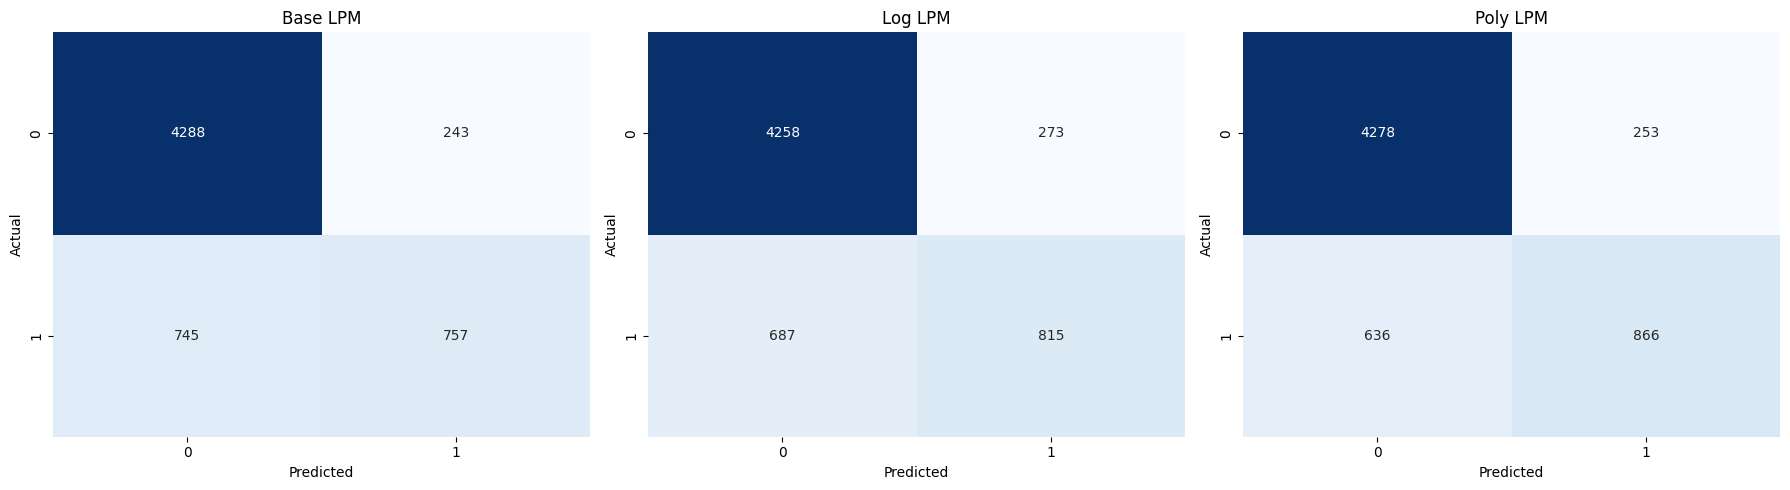

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Base LPM", y_pred_base_class),
    ("Log LPM", y_pred_log_class),
    ("Poly LPM", y_pred_poly_class)
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    ax=ax,
    cbar=False)
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [49]:
results = []

for name, preds in models:
    cm = confusion_matrix(y_test, preds)
    
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "Type I Error (FPR)": fp / (fp + tn) if (fp + tn) != 0 else 0,
        "Type II Error (FNR)": fn / (fn + tp) if (fn + tp) != 0 else 0
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Type I Error (FPR),Type II Error (FNR)
0,Base LPM,0.836234,0.757000,0.503995,0.605116,0.053631,0.496005
1,Log LPM,0.840875,0.749081,0.542610,0.629344,0.060252,0.457390
2,Poly LPM,0.852644,0.773905,0.576565,0.660816,0.055838,0.423435


## Final Notes
- Transformation significantly improves model accuracy (**Poly LPM highest**) 
- Polynomial transformation improves not only accuracy but also all other metrics:  
  - **Accuracy:** increases from 0.836 (Base LPM) → 0.852 (Poly LPM)
  - **Precision:** increases from 0.757 → 0.774
  - **Recall:** increases from 0.504 → 0.577
  - **F1 Score:** increases from 0.605 → 0.661
  - **Type I Error (FPR):** remains low (0.054 → 0.056)
  - **Type II Error (FNR):** decreases from 0.496 → 0.423